/Users/giuseppe/Documents/personal/fyp-vrp/dvrptw-benchmark/.venv/lib/python3.12/site-packages/lightning/pytorch/utilities/parsing.py:213: Attribute 'env' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['env'])`.
/Users/giuseppe/Documents/personal/fyp-vrp/dvrptw-benchmark/.venv/lib/python3.12/site-packages/lightning/pytorch/utilities/parsing.py:213: Attribute 'policy' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['policy'])`.
Using 16bit Automatic Mixed Precision (AMP)
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
/Users/giuseppe/Documents/personal/fyp-vrp/dvrptw-benchmark/.venv/lib/python3.12/site-packages/lightning/pytorch/trainer/connectors/logger_connector/logger_connector.py:76: Starting from v1.9.0, `tensorboardX` has been removed as a dependency of t

strategy='rl4co' routes=[Route(vehicle_id=0, node_ids=[63, 39, 33, 72, 5, 95, 83, 47, 36, 59, 27, 28, 31, 2, 62, 69, 98, 82, 52, 15, 29, 64, 11, 23, 44, 21, 12, 75, 71, 30, 61, 67, 38, 7, 99, 51, 40, 18, 85, 81, 78, 9, 6, 94, 49, 26, 35, 80, 25, 58, 70, 77, 93, 100]), Route(vehicle_id=1, node_ids=[65, 42, 45, 14, 92, 19, 16, 88, 76, 73, 86, 79, 90, 87, 8, 22, 41, 84, 57, 3, 48, 91, 89, 17, 60, 24]), Route(vehicle_id=2, node_ids=[53, 1, 13, 74, 4, 32, 68]), Route(vehicle_id=3, node_ids=[34, 54, 55, 43, 66, 96, 56, 37]), Route(vehicle_id=4, node_ids=[46, 97, 20, 10, 50])] total_distance=54.6607551574707 feasible=True violations={} solve_time_s=0.0 details={}


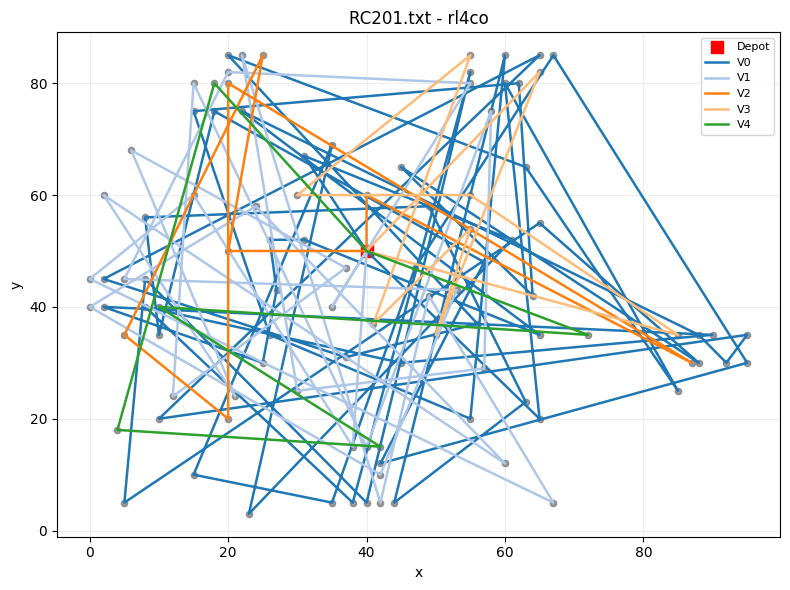

In [1]:
from pathlib import Path

from dvrptw_bench.data.solomon_parser import parse_solomon
from dvrptw_bench.rl.rl4co_policy import RL4COPolicy
from dvrptw_bench.rl.rl_model import RLModel, build_attention_model
from dvrptw_bench.viz.route_plot import plot_routes
from rl4co.envs import CVRPEnv, CVRPTWEnv

weights = "../trained_models/training-abela-100-customer-cvrp.ckpt"
model = build_attention_model()
model.env = CVRPTWEnv(generator_params={"num_loc": 100})
model.load(weights)
policy = RL4COPolicy(model)

instance = parse_solomon(Path('../dataset/solomon_rc100/RC201.txt'))
solution = policy.infer_instance(instance)
print(solution)


plot_routes(instance, solution)

/Users/giuseppe/Documents/personal/fyp-vrp/dvrptw-benchmark/.venv/lib/python3.12/site-packages/lightning/pytorch/utilities/parsing.py:213: Attribute 'env' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['env'])`.
/Users/giuseppe/Documents/personal/fyp-vrp/dvrptw-benchmark/.venv/lib/python3.12/site-packages/lightning/pytorch/utilities/parsing.py:213: Attribute 'policy' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['policy'])`.
Using 16bit Automatic Mixed Precision (AMP)
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
/Users/giuseppe/D

strategy='rl4co' routes=[Route(vehicle_id=0, node_ids=[65, 92, 42, 45, 14, 36, 63, 59, 72, 39, 5, 33, 95, 83, 47, 27, 28, 2, 82, 69, 31, 62, 98, 15, 52, 64, 29, 11, 23, 44, 7, 6, 80, 25, 48, 58, 70, 77, 93, 100]), Route(vehicle_id=1, node_ids=[21, 12, 75, 71, 30, 16, 19, 61, 88, 67, 38, 78, 89, 1, 4, 13, 17, 24, 35, 60, 91]), Route(vehicle_id=2, node_ids=[76]), Route(vehicle_id=3, node_ids=[73]), Route(vehicle_id=4, node_ids=[99]), Route(vehicle_id=5, node_ids=[51, 94, 74, 32, 68, 54, 55]), Route(vehicle_id=6, node_ids=[40, 57, 43, 66, 96, 56, 37, 97, 20, 26]), Route(vehicle_id=7, node_ids=[18, 84, 10, 50, 46, 34, 3]), Route(vehicle_id=8, node_ids=[85]), Route(vehicle_id=9, node_ids=[86]), Route(vehicle_id=10, node_ids=[79]), Route(vehicle_id=11, node_ids=[81]), Route(vehicle_id=12, node_ids=[87]), Route(vehicle_id=13, node_ids=[90]), Route(vehicle_id=14, node_ids=[8]), Route(vehicle_id=15, node_ids=[9]), Route(vehicle_id=16, node_ids=[53, 41, 22, 49])] total_distance=55.71261215209961

55.71261215209961

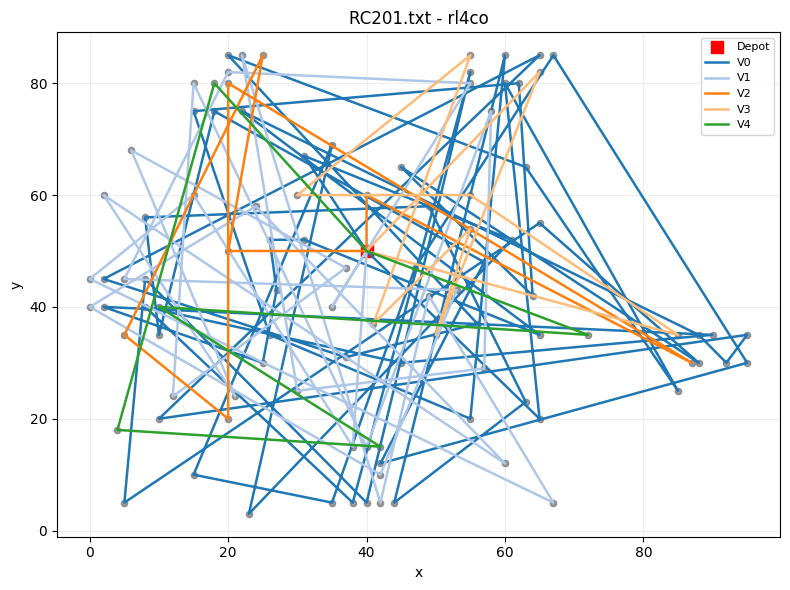

In [5]:
weights = "../trained_models/training-abela-100-customer-cvrp-4090.ckpt"
model = build_attention_model()
model.env = CVRPTWEnv(generator_params={"num_loc": 100})
model.load(weights)
policy = RL4COPolicy(model)

instance = parse_solomon(Path('../dataset/solomon_rc100/RC201.txt'))
solution_4090 = policy.infer_instance(instance)
print(solution_4090)


plot_routes(instance, solution)
solution_4090.total_distance

In [ ]:
solution_4090.total_distance, solution.total_distance

(55.71261215209961, 54.6607551574707)

In [8]:
GAP = (solution_4090.total_distance - solution.total_distance) / solution.total_distance * 100
print(f"GAP: {GAP:.2f}%")

GAP: 1.92%
